In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [10]:
# load data set
df = pd.read_excel("IPO data.xlsx")

In [11]:
print("Shape: ",df.shape)
print("Columns: ",df.columns.tolist())
print("Datatypes: \n",df.dtypes)

Shape:  (652, 10)
Columns:  ['Date', 'IPO_Name', 'Issue_Size(crores)', 'QIB', 'HNI', 'RII', 'Total', 'Offer Price', 'List Price', 'Listing Gain']
Datatypes: 
 Date                  datetime64[us]
IPO_Name                         str
Issue_Size(crores)           float64
QIB                          float64
HNI                          float64
RII                          float64
Total                        float64
Offer Price                    int64
List Price                   float64
Listing Gain                 float64
dtype: object


In [12]:
print("Frist 5 Rows: \n",df.head())

Frist 5 Rows: 
         Date                        IPO_Name  Issue_Size(crores)    QIB  \
0 2026-05-14       Bagmane Prime Office REIT             3405.00  17.09   
1 2026-05-08  Onemi Technology Solutions Ltd              925.92  24.87   
2 2026-04-29       Citius Transnet India Ltd             1105.00   8.54   
3 2026-04-17       Om Power Transmission Ltd              150.06   3.65   
4 2026-04-02             Sai Parenterals Ltd              408.79   1.71   

     HNI   RII  Total  Offer Price  List Price  Listing Gain  
0  15.79  0.00  16.50          100       103.4          3.40  
1   6.57  2.03   9.50          171       191.0         11.70  
2  11.77  0.00  10.01          100       104.5          4.50  
3   7.06  1.54   3.33          175       181.1          3.49  
4   2.36  0.12   1.05          392       405.0          3.32  


In [13]:
#data cleaning
print(df.isnull().sum())

Date                  0
IPO_Name              0
Issue_Size(crores)    0
QIB                   2
HNI                   2
RII                   2
Total                 2
Offer Price           0
List Price            0
Listing Gain          2
dtype: int64


In [14]:
df=df.dropna()
print("Missing values after cleaning: \n",df.isnull().sum())
print("Shape after cleaning: ",df.shape)


Missing values after cleaning: 
 Date                  0
IPO_Name              0
Issue_Size(crores)    0
QIB                   0
HNI                   0
RII                   0
Total                 0
Offer Price           0
List Price            0
Listing Gain          0
dtype: int64
Shape after cleaning:  (648, 10)


Positive Listing Gain: 444 (68.5%)
Negative Listing Gain: 165 (25.5%)
Average Listing Gain: 16.5


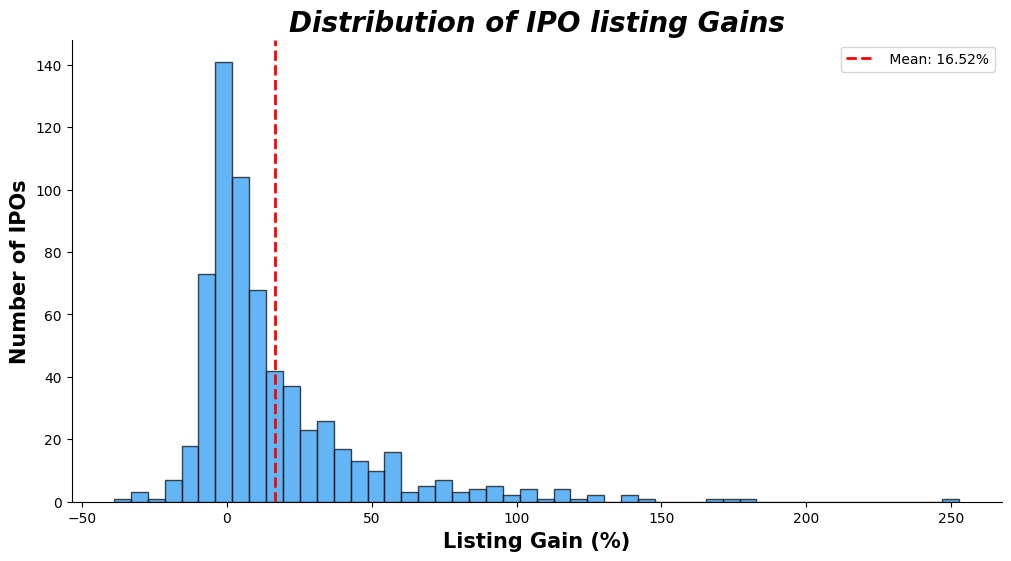

In [15]:
#listing gains
plt.figure(figsize=(12,6))
plt.hist(df['Listing Gain'],bins=50,color='#2196F3',edgecolor='black',alpha=0.7)
plt.axvline(df['Listing Gain'].mean(), color='red', linestyle='dashed', linewidth=2,label=f" Mean: {df['Listing Gain'].mean().round(2)}%")

plt.title('Distribution of IPO listing Gains',fontsize=20,fontweight='bold',fontstyle='italic')
plt.xlabel('Listing Gain (%)',fontsize=15,fontweight='bold')
plt.ylabel('Number of IPOs',fontsize=15,fontweight='bold')
plt.legend()
sns.despine(left=False,right=True)
plt.savefig('listing_gain_distribution.png',dpi=300,bbox_inches='tight')

#key stats
print(f"Positive Listing Gain: {(df['Listing Gain']>0).sum()} ({(((df['Listing Gain']>0).sum())/len(df)*100).round(1)}%)")
print(f"Negative Listing Gain: {(df['Listing Gain']<0).sum()} ({(((df['Listing Gain']<0).sum())/len(df)*100).round(1)}%)")
print(f"Average Listing Gain: {df['Listing Gain'].mean().round(1)}")

OBSERVATION #1:-    
About 68.5% of Indian IPOs list with gains, but the average gain of 16.5% is misleading because a few extreme winners (100%+ listings) distort it. Most IPOs actually move within -10% to +20% on listing day. A better strategy is to target IPOs likely to deliver moderate 20–50% gains, rather than chasing rare outliers.

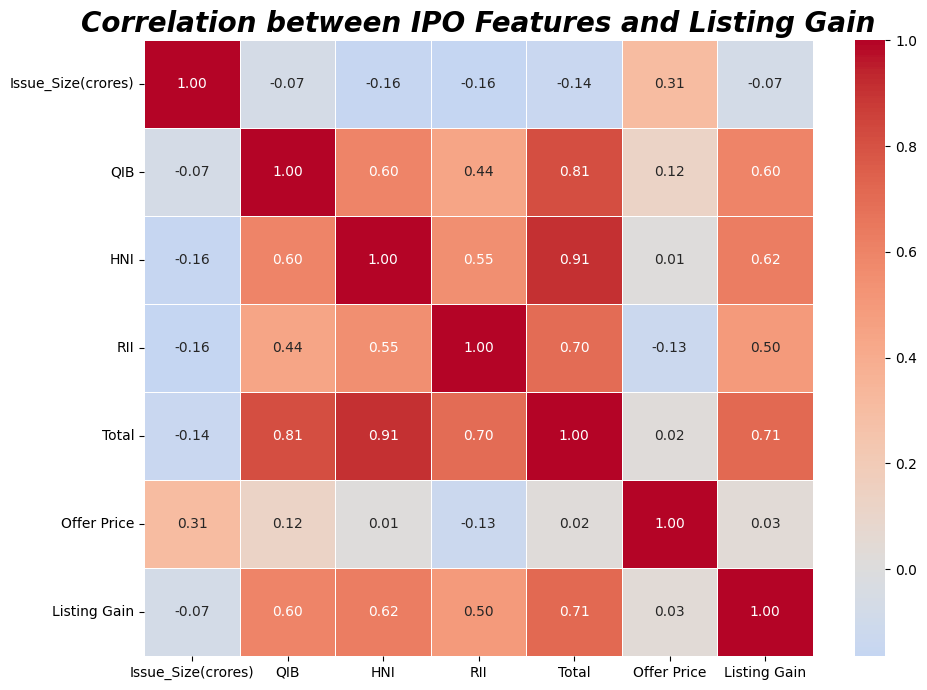

In [16]:
#which factor strongly affect the listing gains usinf correlation


cols=['Issue_Size(crores)','QIB','HNI','RII','Total','Offer Price','Listing Gain']
corr_mat=df[cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr_mat,annot=True,fmt='.2f',cmap='coolwarm',center=0,linewidth=0.5)
plt.title('Correlation between IPO Features and Listing Gain',fontsize=20,fontweight='bold',fontstyle='italic')
plt.tight_layout()
plt.savefig('corr_heatmap.png',dpi=300,bbox_inches='tight')

OBSERVATION #2:-    
Total subscription rate (0.71 correlation) is the strongest predictor of IPO listing gains followed by HNI (0.62) and QIB (0.60) interest. Offer price has almost zero impact. Smart investors should track institutional and HNI subscription data before applying.

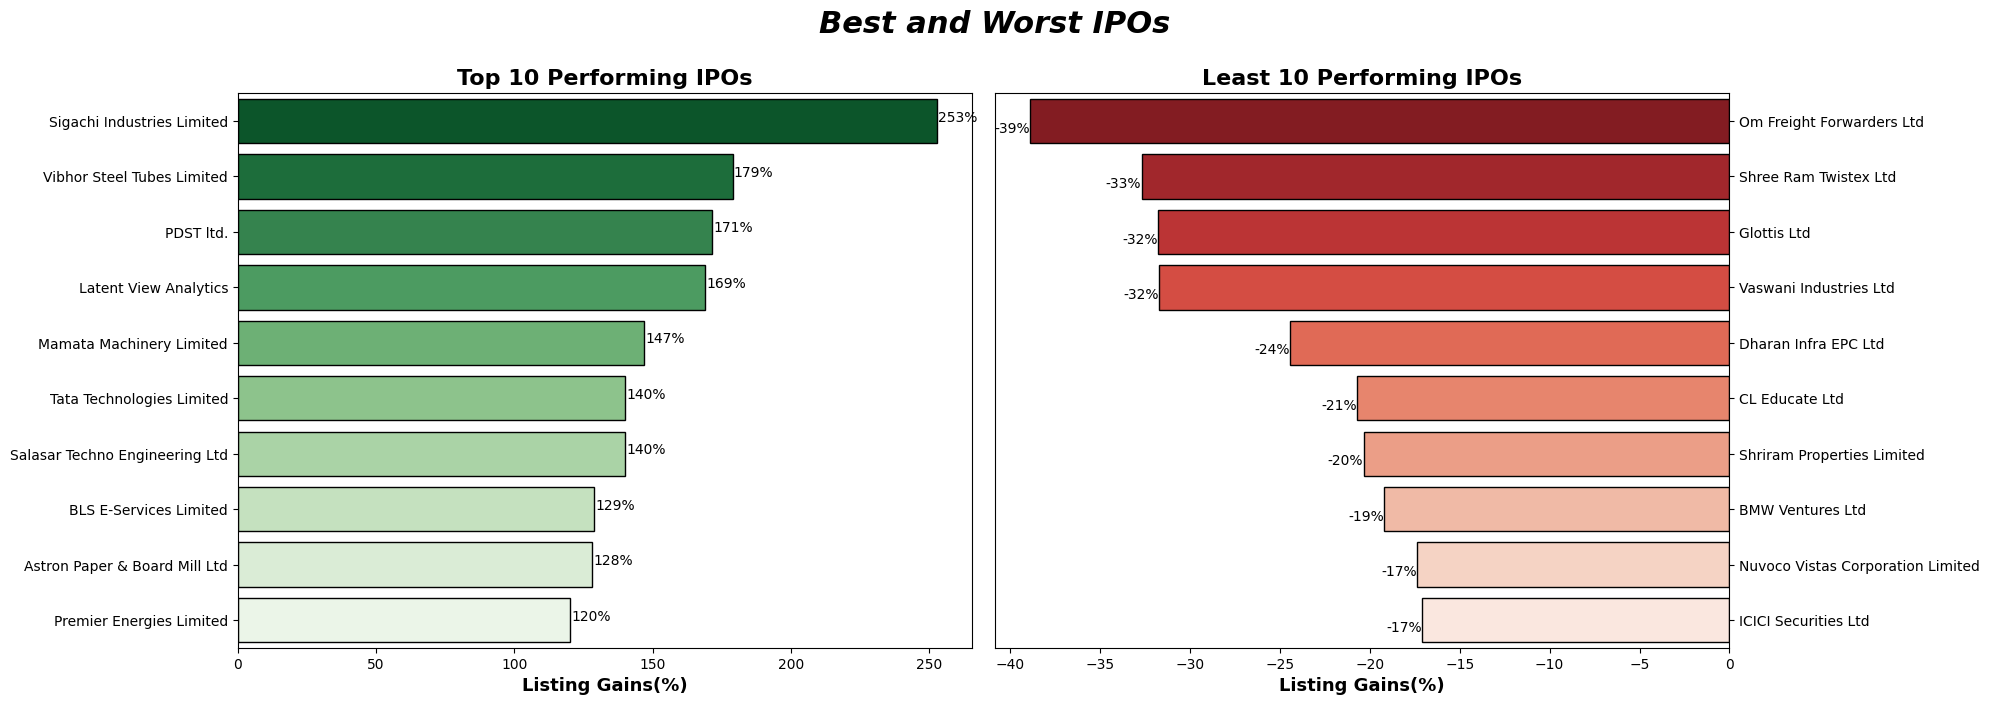

In [17]:
# top 10 and bottom 10

top10=df.nlargest(10,'Listing Gain')[['IPO_Name','Listing Gain']]
bottom10=df.nsmallest(10,'Listing Gain')[['IPO_Name','Listing Gain']]\

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(20,7))

#top 10
sns.barplot(data=top10,x='Listing Gain',y='IPO_Name',hue='IPO_Name',ax=ax1,palette='Greens_r',edgecolor='black')
ax1.set_title('Top 10 Performing IPOs',fontsize=16,fontweight='bold')
ax1.set_xlabel('Listing Gains(%)',fontsize=13,fontweight='bold')
ax1.set_ylabel('')
for i,v in enumerate (top10['Listing Gain']):
    ax1.text(v+0.5,i,f'{v:.0f}%')


#bottom 10
sns.barplot(data=bottom10,x='Listing Gain',y='IPO_Name',hue='IPO_Name',ax=ax2,palette='Reds_r',edgecolor='black')
ax2.set_title('Least 10 Performing IPOs',fontsize=16,fontweight='bold')
ax2.set_xlabel('Listing Gains(%)',fontsize=13,fontweight='bold')
ax2.set_ylabel('')
ax2.yaxis.tick_right()
for i,v in enumerate (bottom10['Listing Gain']):
    ax2.text(v-2,i+0.2,f'{v:.0f}%')


fig.suptitle('Best and Worst IPOs',fontsize=22,fontweight='bold',fontstyle='italic',va='center')
plt.tight_layout()
plt.savefig('best_worst_ipo.png',dpi=300,bbox_inches='tight')

OBSERVATION #3:-        
Sigachi Industries listed at 253% gain — the highest in recent IPO history. However, Om Freight Forwarders lost 39% on listing day. This shows IPO investing carries real risk — without data-driven selection, losses are inevitable.

In [18]:
df.head()

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain
0,2026-05-14,Bagmane Prime Office REIT,3405.00,17.09,15.79,0.00,16.50,100,103.4,3.40
1,2026-05-08,Onemi Technology Solutions Ltd,925.92,24.87,6.57,2.03,9.50,171,191.0,11.70
2,2026-04-29,Citius Transnet India Ltd,1105.00,8.54,11.77,0.00,10.01,100,104.5,4.50
3,2026-04-17,Om Power Transmission Ltd,150.06,3.65,7.06,1.54,3.33,175,181.1,3.49
4,2026-04-02,Sai Parenterals Ltd,408.79,1.71,2.36,0.12,1.05,392,405.0,3.32


In [ ]:
#feature engineering 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

df=df[df['Listing Gain']<150]
X=df[['Issue_Size(crores)','QIB','HNI','RII','Total','Offer Price']]
y=df['Listing Gain']

print('Feature shape: ',X.shape)
print('target shape: ',y.shape)
print('feature stats: \n',X.describe())

Feature shape:  (644, 6)
target shape:  (644,)
feature stats: 
        Issue_Size(crores)         QIB         HNI         RII       Total  \
count          644.000000  644.000000  644.000000  644.000000  644.000000   
mean          1445.564441   48.316863   67.770016   15.278323   35.905885   
std           2639.801503   66.313467  120.106264   31.307059   49.731409   
min             23.000000    0.000000    0.000000    0.000000    0.110000   
25%            270.150000    2.605000    1.840000    1.397500    2.257500   
50%            599.425000   13.450000   13.215000    4.775000   10.700000   
75%           1256.715000   75.455000   73.740000   14.130000   54.975000   
max          27858.800000  420.570000  958.070000  374.810000  300.610000   

       Offer Price  
count   644.000000  
mean    359.840062  
std     328.229547  
min      10.000000  
25%     120.000000  
50%     253.500000  
75%     485.250000  
max    2165.000000  


In [60]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled= scaler.fit_transform(X)

#train and test
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=17)

print('training set',X_train.shape)
print('testing set',X_test.shape)
y_train.head()

training set (515, 6)
testing set (129, 6)


479     4.65
12     11.69
458    67.79
36     -4.21
107    28.31
Name: Listing Gain, dtype: float64

In [69]:
# model 1 - linear regression
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)

# model 2 - random forest 
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100,random_state=17)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

# model 3 - gradiant boosting regressor
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor(n_estimators=100,random_state=17)
gb.fit(X_train,y_train)
gb_pred=gb.predict(X_test)


print('='*46)
print(f"{'Model':<25} {'R2':>6} {'MAE':>6} {'MSE':>6}")
for name, pred in [('Linear Regression',lr_pred),('Random Forest',rf_pred),('Gradient Boosting',gb_pred)]:
    r2=r2_score(y_test,pred)
    mae=mean_absolute_error(y_test,pred)
    mse=mean_squared_error(y_test,pred)
    print(f'{name:<25} {r2:>6.2f} {mae:>6.2f} {mse:>6.2f}')
print('='*46)

Model                         R2    MAE    MSE
Linear Regression           0.54  12.54 358.89
Random Forest               0.45  13.67 435.50
Gradient Boosting           0.38  13.83 488.44


In [70]:
import pickle
import os

os.makedirs('model',exist_ok=True)

with open('model/ipo_model.pkl','wb') as f:
    pickle.dump(lr,f)

with open('model/ipo_scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

print('MODEL SAVED')
print('SCALER SAVED')

MODEL SAVED
SCALER SAVED
